In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_nyc=pd.read_csv(r"C:\Users\DELL\Downloads\nyc_taxi_trip_duration.csv")

In [3]:
df_nyc.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,29-02-2016 16:40,29-02-2016 16:47,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,11-03-2016 23:35,11-03-2016 23:53,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,21-02-2016 17:59,21-02-2016 18:26,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,05-01-2016 09:44,05-01-2016 10:03,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,17-02-2016 06:42,17-02-2016 06:56,1,-74.017120,40.708469,-73.988182,40.740631,N,848


In [4]:
df_nyc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  729322 non-null  object 
 1   vendor_id           729322 non-null  int64  
 2   pickup_datetime     729322 non-null  object 
 3   dropoff_datetime    729322 non-null  object 
 4   passenger_count     729322 non-null  int64  
 5   pickup_longitude    729322 non-null  float64
 6   pickup_latitude     729322 non-null  float64
 7   dropoff_longitude   729322 non-null  float64
 8   dropoff_latitude    729322 non-null  float64
 9   store_and_fwd_flag  729322 non-null  object 
 10  trip_duration       729322 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 61.2+ MB


In [5]:
df_nyc.shape

(729322, 11)

In [6]:
df_nyc.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [7]:
df_nyc.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,729322.000000,729322.000000,729322.000000,729322.000000,729322.000000,729322.000000,7.293220e+05
mean,1.535403,1.662055,-73.973513,40.750919,-73.973422,40.751775,9.522291e+02
std,0.498745,1.312446,0.069754,0.033594,0.069588,0.036037,3.864626e+03
min,1.000000,0.000000,-121.933342,34.712235,-121.933304,32.181141,1.000000e+00
25%,1.000000,1.000000,-73.991859,40.737335,-73.991318,40.735931,3.970000e+02
50%,2.000000,1.000000,-73.981758,40.754070,-73.979759,40.754509,6.630000e+02
75%,2.000000,2.000000,-73.967361,40.768314,-73.963036,40.769741,1.075000e+03
max,2.000000,9.000000,-65.897385,51.881084,-65.897385,43.921028,1.939736e+06


In [8]:
df_nyc.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [9]:
df_nyc['pickup_datetime'] = pd.to_datetime(df_nyc['pickup_datetime'], format='%d-%m-%Y %H:%M')
df_nyc['dropoff_datetime'] = pd.to_datetime(df_nyc['dropoff_datetime'], format='%d-%m-%Y %H:%M')
df_nyc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  729322 non-null  object        
 1   vendor_id           729322 non-null  int64         
 2   pickup_datetime     729322 non-null  datetime64[ns]
 3   dropoff_datetime    729322 non-null  datetime64[ns]
 4   passenger_count     729322 non-null  int64         
 5   pickup_longitude    729322 non-null  float64       
 6   pickup_latitude     729322 non-null  float64       
 7   dropoff_longitude   729322 non-null  float64       
 8   dropoff_latitude    729322 non-null  float64       
 9   store_and_fwd_flag  729322 non-null  object        
 10  trip_duration       729322 non-null  int64         
dtypes: datetime64[ns](2), float64(4), int64(3), object(2)
memory usage: 61.2+ MB


Descriptive statistics for trip_duration:
count    7.293220e+05
mean     9.522291e+02
std      3.864626e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.630000e+02
75%      1.075000e+03
max      1.939736e+06
Name: trip_duration, dtype: float64


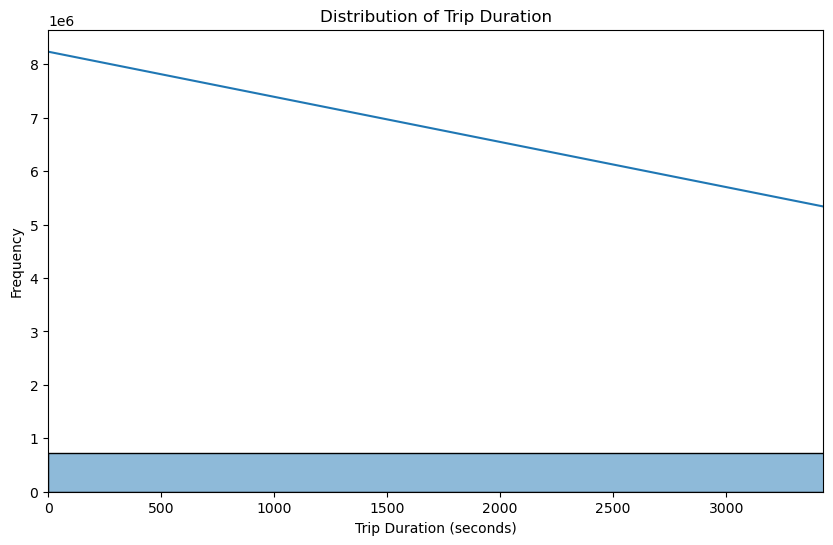

In [10]:
print('Descriptive statistics for trip_duration:')
print(df_nyc['trip_duration'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_nyc['trip_duration'], bins=50, kde=True)
plt.title('Distribution of Trip Duration')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Frequency')
plt.xlim(0, df_nyc['trip_duration'].quantile(0.99))
plt.show()

Value counts for vendor_id:
vendor_id
2    390481
1    338841
Name: count, dtype: int64


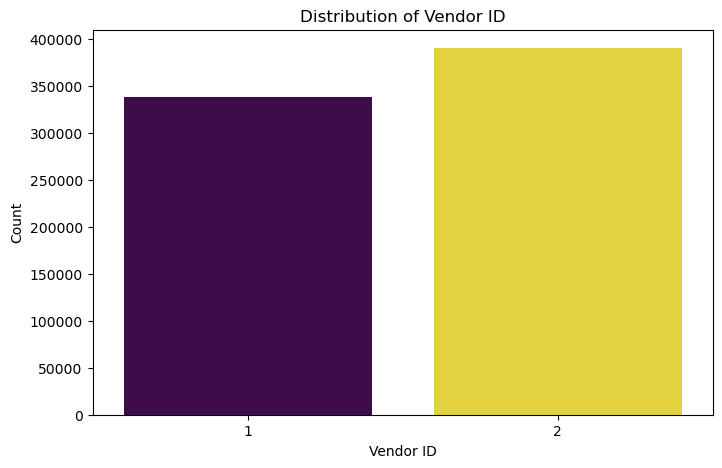

In [11]:
print('Value counts for vendor_id:')
print(df_nyc['vendor_id'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x='vendor_id', data=df_nyc, palette='viridis', hue='vendor_id', legend=False)
plt.title('Distribution of Vendor ID')
plt.xlabel('Vendor ID')
plt.ylabel('Count')
plt.show()

Descriptive statistics for passenger_count:
count    729322.000000
mean          1.662055
std           1.312446
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           9.000000
Name: passenger_count, dtype: float64

Value counts for passenger_count:
passenger_count
1    517415
2    105097
5     38926
3     29692
6     24107
4     14050
0        33
7         1
9         1
Name: count, dtype: int64


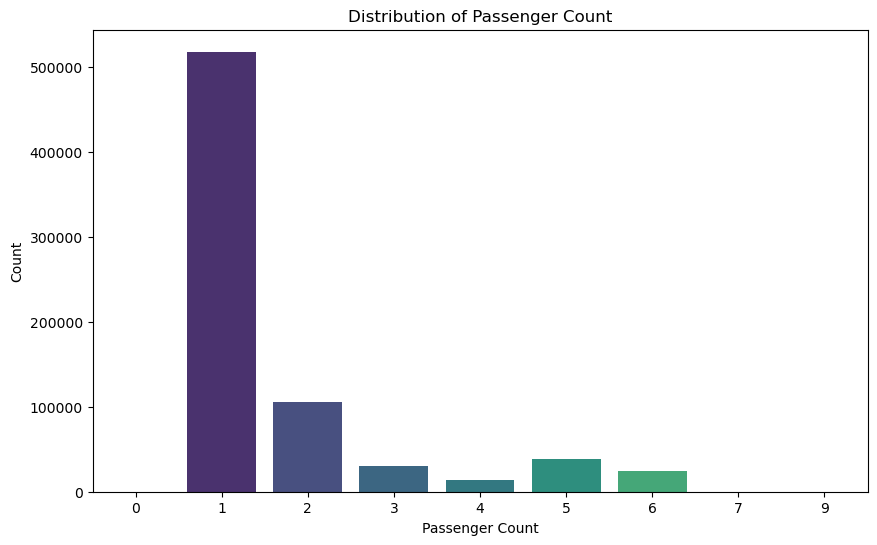

In [12]:
print('Descriptive statistics for passenger_count:')
print(df_nyc['passenger_count'].describe())

print('\nValue counts for passenger_count:')
print(df_nyc['passenger_count'].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(x='passenger_count', data=df_nyc, palette='viridis', hue='passenger_count', legend=False)
plt.title('Distribution of Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Count')
plt.show()

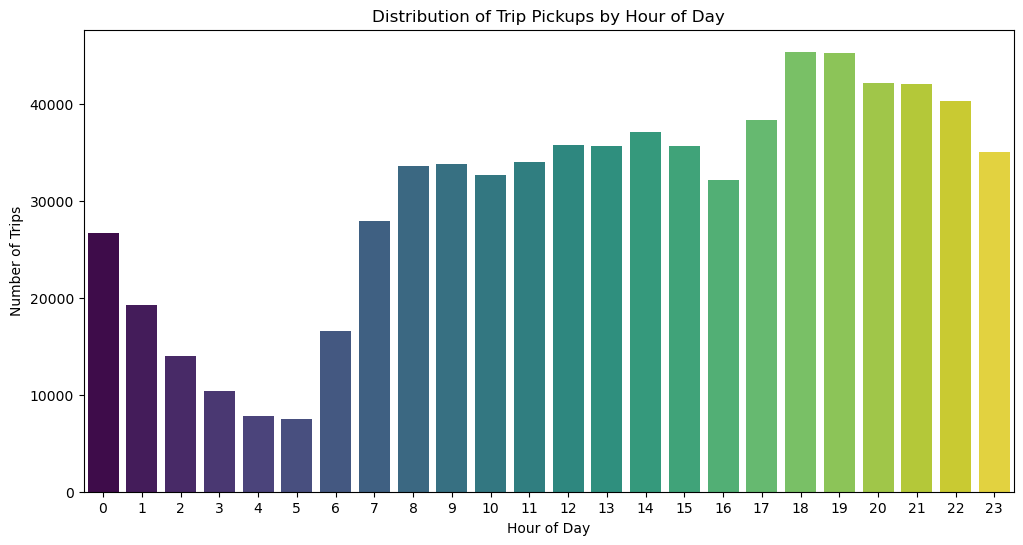

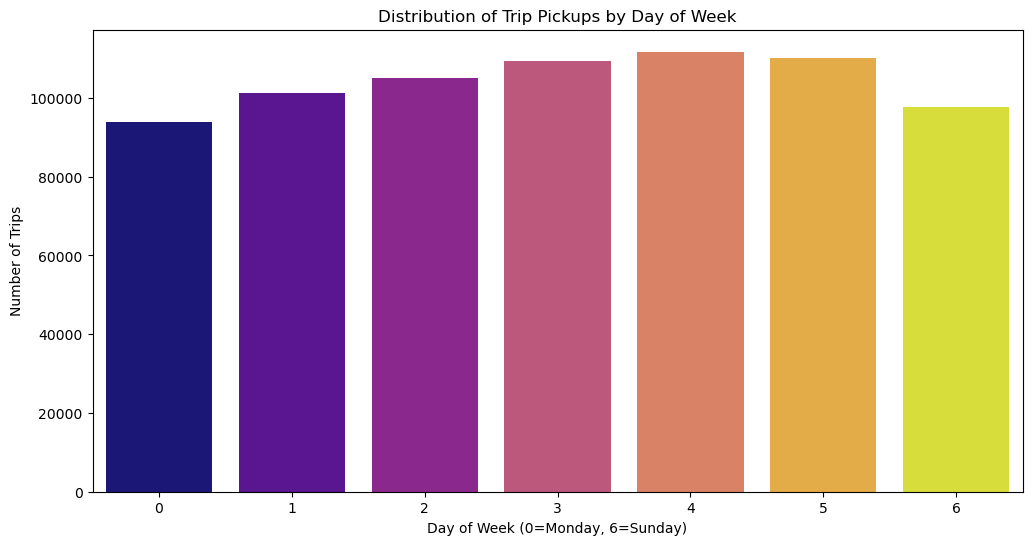

In [13]:
df_nyc['pickup_hour'] = df_nyc['pickup_datetime'].dt.hour
df_nyc['pickup_day_of_week'] = df_nyc['pickup_datetime'].dt.dayofweek

plt.figure(figsize=(12, 6))
sns.countplot(x='pickup_hour', data=df_nyc, palette='viridis', hue='pickup_hour', legend=False)
plt.title('Distribution of Trip Pickups by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(x='pickup_day_of_week', data=df_nyc, palette='plasma', hue='pickup_day_of_week', legend=False)
plt.title('Distribution of Trip Pickups by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Number of Trips')
plt.show()

Value counts for store_and_fwd_flag:
store_and_fwd_flag
N    725282
Y      4040
Name: count, dtype: int64


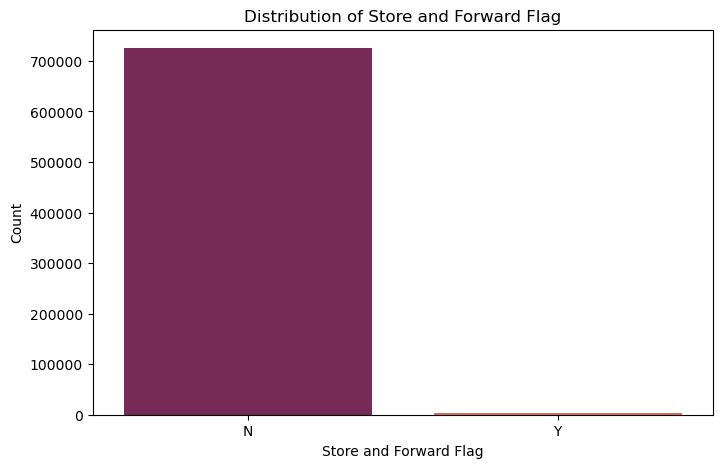

In [14]:
print('Value counts for store_and_fwd_flag:')
print(df_nyc['store_and_fwd_flag'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x='store_and_fwd_flag', data=df_nyc, palette='rocket', hue='store_and_fwd_flag', legend=False)
plt.title('Distribution of Store and Forward Flag')
plt.xlabel('Store and Forward Flag')
plt.ylabel('Count')
plt.show()

Descriptive statistics for pickup_longitude:
count    729322.000000
mean        -73.973513
std           0.069754
min        -121.933342
25%         -73.991859
50%         -73.981758
75%         -73.967361
max         -65.897385
Name: pickup_longitude, dtype: float64

Descriptive statistics for pickup_latitude:
count    729322.000000
mean         40.750919
std           0.033594
min          34.712235
25%          40.737335
50%          40.754070
75%          40.768314
max          51.881084
Name: pickup_latitude, dtype: float64

Descriptive statistics for dropoff_longitude:
count    729322.000000
mean        -73.973422
std           0.069588
min        -121.933304
25%         -73.991318
50%         -73.979759
75%         -73.963036
max         -65.897385
Name: dropoff_longitude, dtype: float64

Descriptive statistics for dropoff_latitude:
count    729322.000000
mean         40.751775
std           0.036037
min          32.181141
25%          40.735931
50%          40.754509
75%       

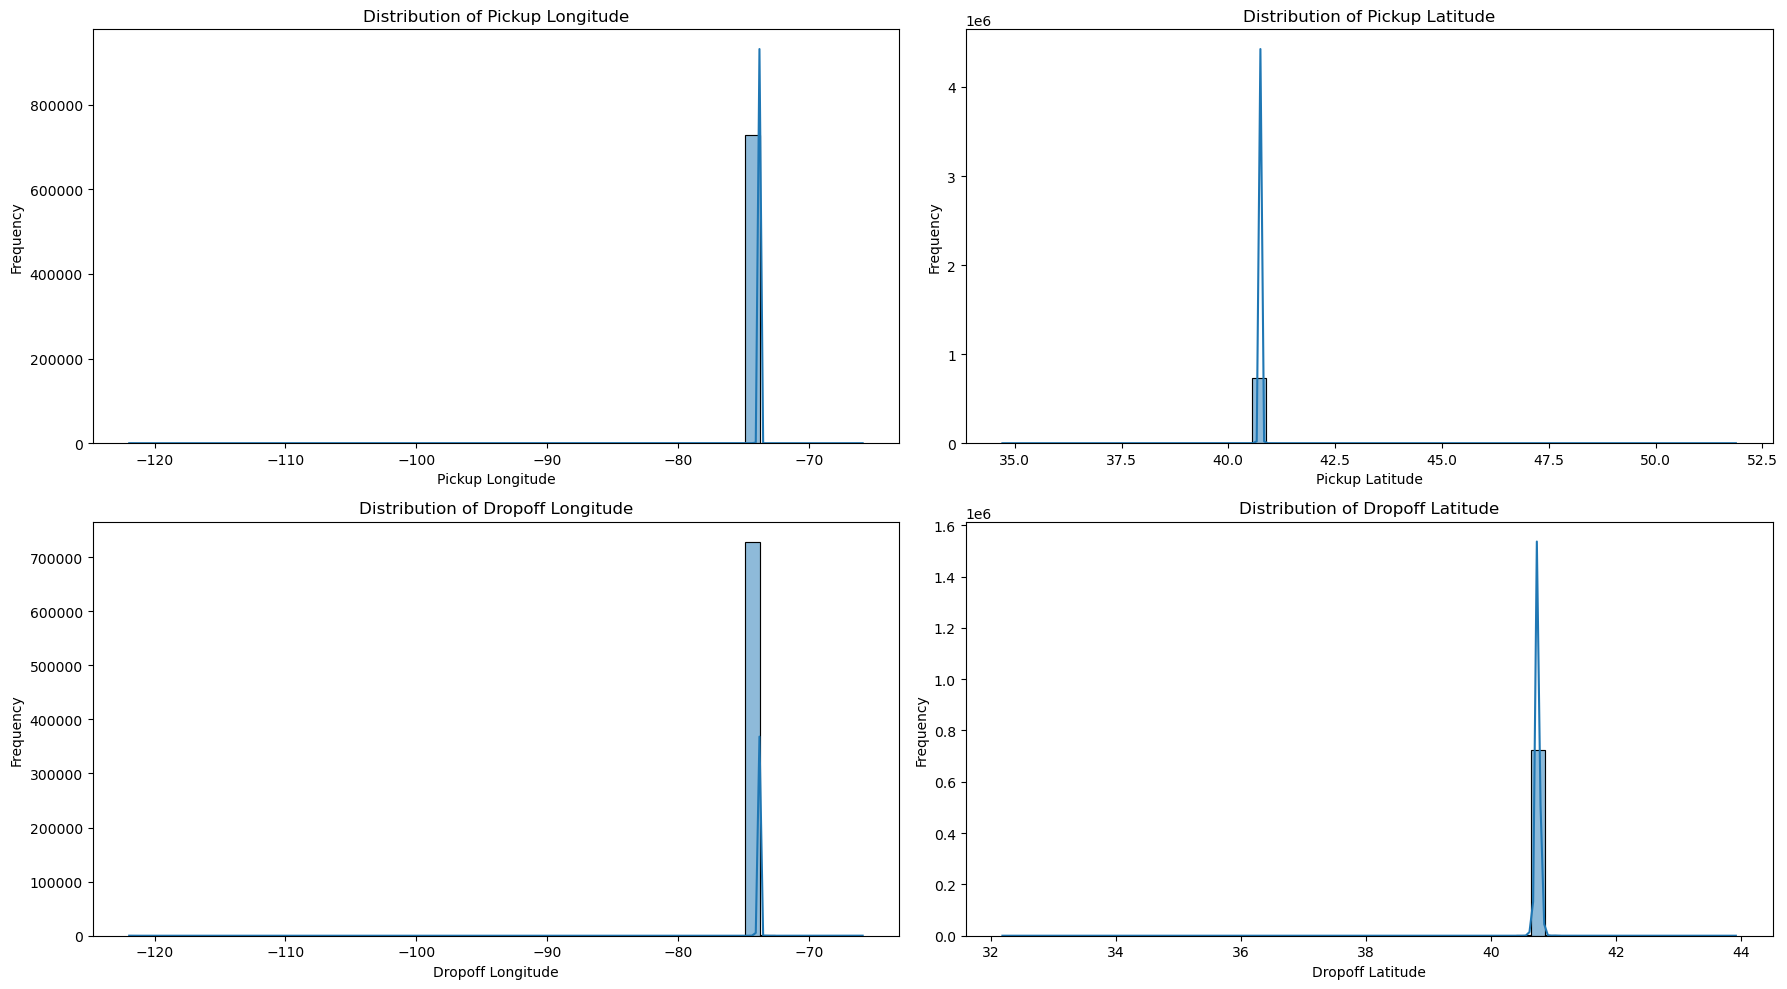

In [15]:
print('Descriptive statistics for pickup_longitude:')
print(df_nyc['pickup_longitude'].describe())
print('\nDescriptive statistics for pickup_latitude:')
print(df_nyc['pickup_latitude'].describe())
print('\nDescriptive statistics for dropoff_longitude:')
print(df_nyc['dropoff_longitude'].describe())
print('\nDescriptive statistics for dropoff_latitude:')
print(df_nyc['dropoff_latitude'].describe())

plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1)
sns.histplot(df_nyc['pickup_longitude'], bins=50, kde=True)
plt.title('Distribution of Pickup Longitude')
plt.xlabel('Pickup Longitude')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
sns.histplot(df_nyc['pickup_latitude'], bins=50, kde=True)
plt.title('Distribution of Pickup Latitude')
plt.xlabel('Pickup Latitude')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
sns.histplot(df_nyc['dropoff_longitude'], bins=50, kde=True)
plt.title('Distribution of Dropoff Longitude')
plt.xlabel('Dropoff Longitude')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
sns.histplot(df_nyc['dropoff_latitude'], bins=50, kde=True)
plt.title('Distribution of Dropoff Latitude')
plt.xlabel('Dropoff Latitude')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

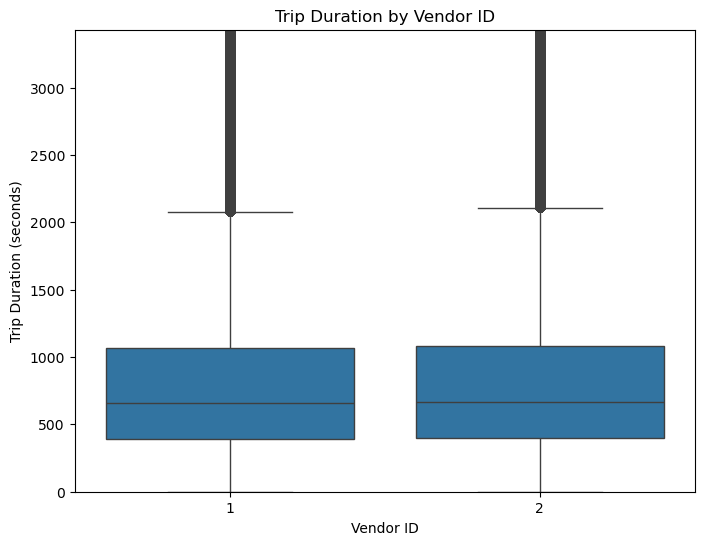

In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='vendor_id', y='trip_duration', data=df_nyc)
plt.title('Trip Duration by Vendor ID')
plt.xlabel('Vendor ID')
plt.ylabel('Trip Duration (seconds)')
plt.ylim(0, df_nyc['trip_duration'].quantile(0.99))
plt.show()

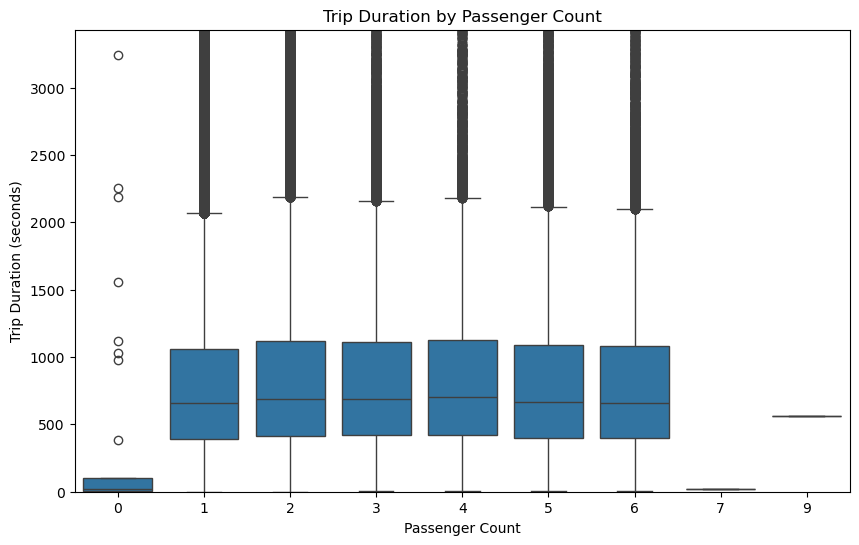

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='passenger_count', y='trip_duration', data=df_nyc)
plt.title('Trip Duration by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Trip Duration (seconds)')
plt.ylim(0, df_nyc['trip_duration'].quantile(0.99))
plt.show()

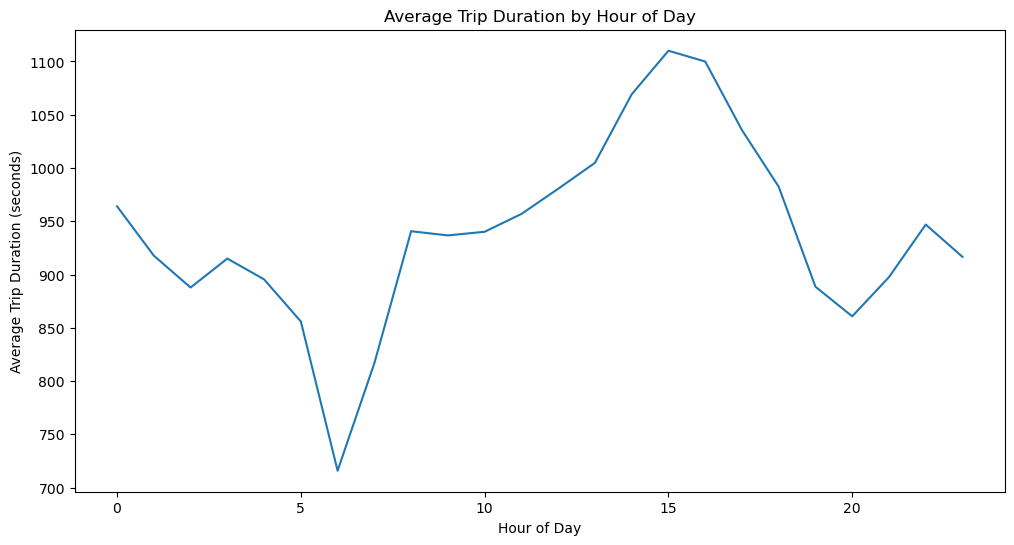

In [18]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='pickup_hour', y='trip_duration', data=df_nyc.groupby('pickup_hour')['trip_duration'].mean().reset_index())
plt.title('Average Trip Duration by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Trip Duration (seconds)')
plt.show()

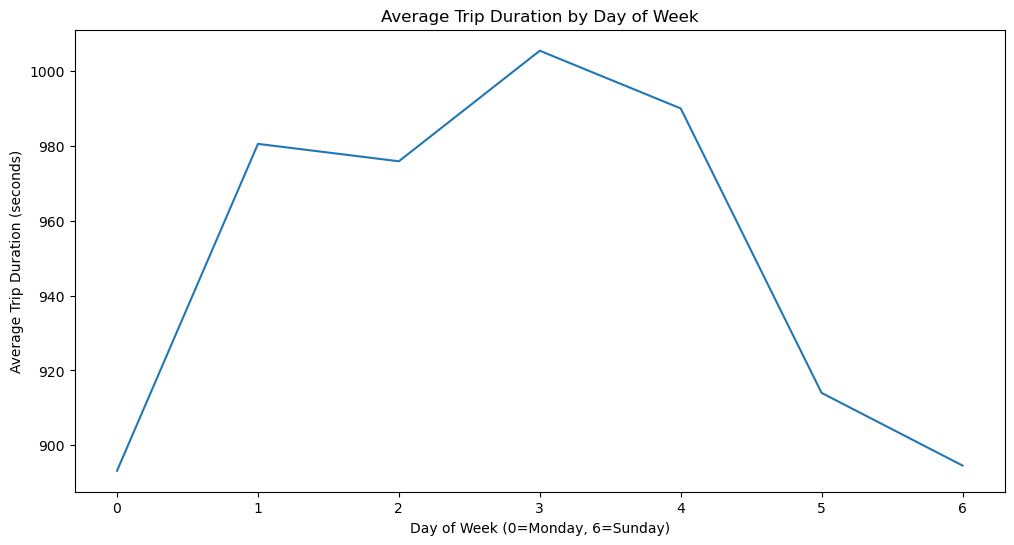

In [19]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='pickup_day_of_week', y='trip_duration', data=df_nyc.groupby('pickup_day_of_week')['trip_duration'].mean().reset_index())
plt.title('Average Trip Duration by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Trip Duration (seconds)')
plt.show()

<Figure size 1500x1500 with 0 Axes>

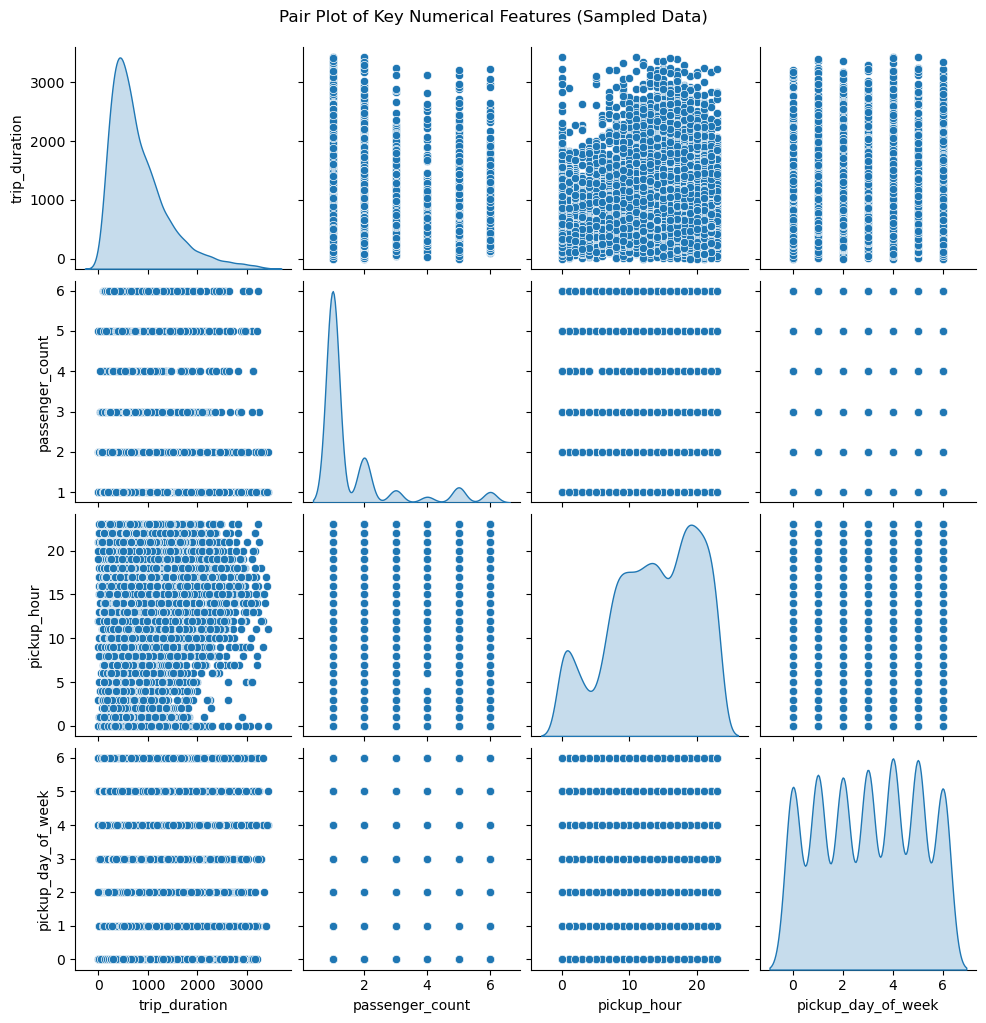

In [20]:
features_for_pairplot = ['trip_duration', 'passenger_count', 'pickup_hour', 'pickup_day_of_week']
df_pairplot = df_nyc[features_for_pairplot].copy()

df_pairplot_sample = df_pairplot.sample(n=10000, random_state=42)

df_pairplot_sample = df_pairplot_sample[df_pairplot_sample['trip_duration'] < df_nyc['trip_duration'].quantile(0.99)]

plt.figure(figsize=(15, 15))
sns.pairplot(df_pairplot_sample, diag_kind='kde')
plt.suptitle('Pair Plot of Key Numerical Features (Sampled Data)', y=1.02) # Adjust suptitle position
plt.show()

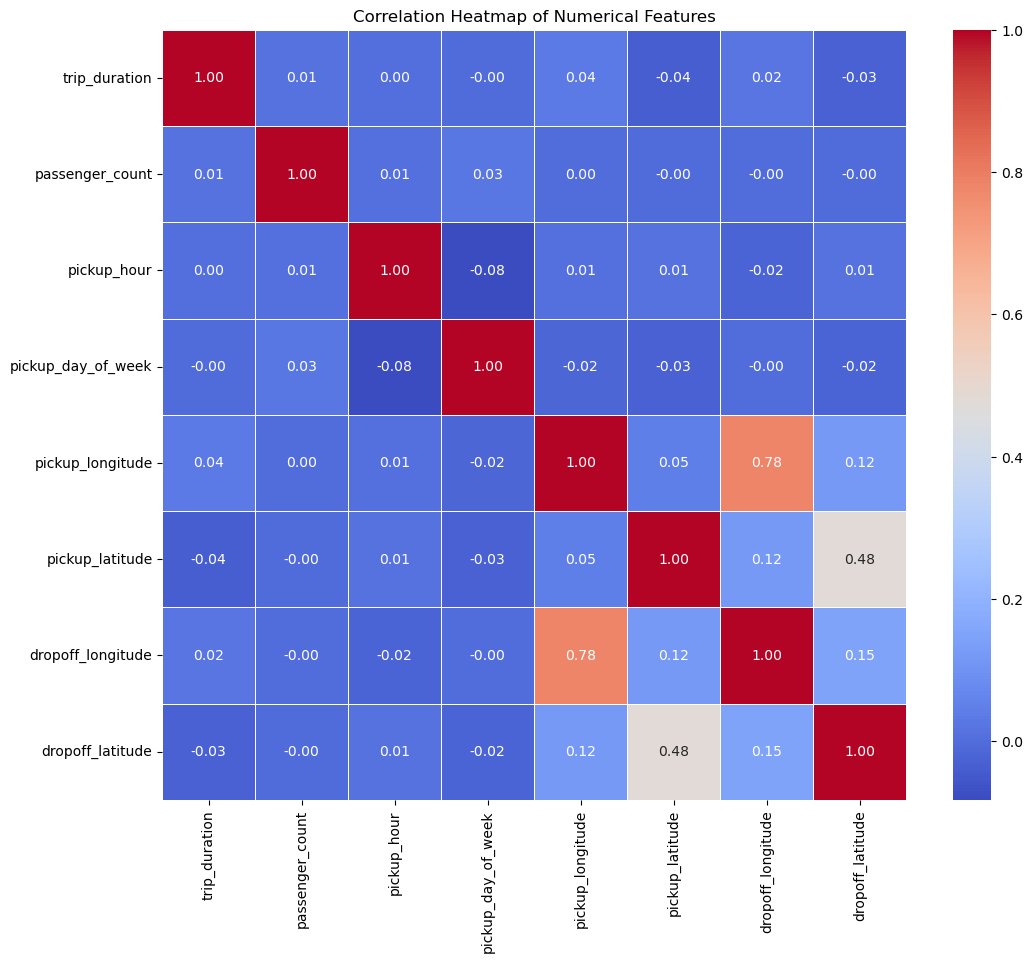

In [21]:
features_for_heatmap = ['trip_duration', 'passenger_count', 'pickup_hour', 'pickup_day_of_week',
                        'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']

df_heatmap = df_nyc[features_for_heatmap]

correlation_matrix = df_heatmap.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Original trip_duration min: 1
Original trip_duration max: 1939736
Lower bound (0.01 percentile): 2.0
Upper bound (99.99 percentile): 86327.0

Shape before filtering trip_duration outliers: (729322, 13)
Shape after filtering trip_duration outliers: (729237, 13)

Descriptive statistics for filtered trip_duration:
count    729237.000000
mean        941.273085
std        3012.038366
min           2.000000
25%         397.000000
50%         663.000000
75%        1075.000000
max       86327.000000
Name: trip_duration, dtype: float64


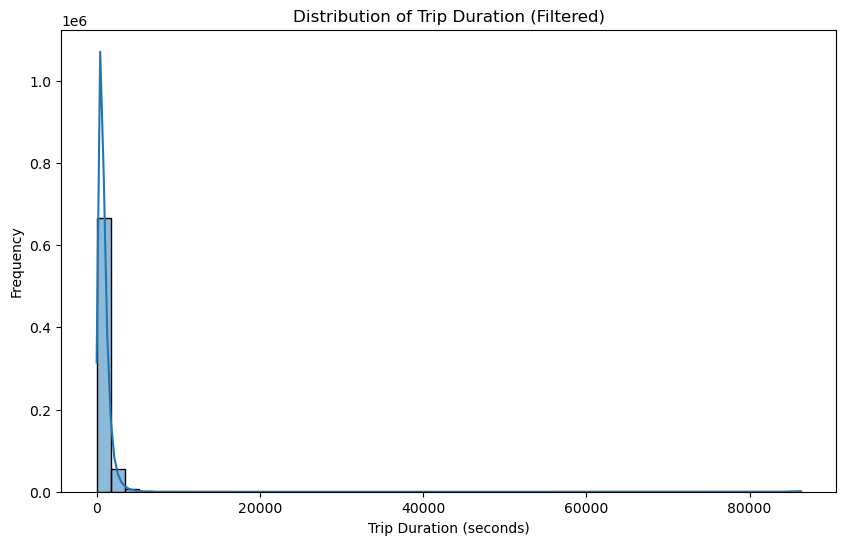

In [22]:
lower_bound = df_nyc['trip_duration'].quantile(0.0001)
upper_bound = df_nyc['trip_duration'].quantile(0.9999)

print(f"Original trip_duration min: {df_nyc['trip_duration'].min()}")
print(f"Original trip_duration max: {df_nyc['trip_duration'].max()}")
print(f"Lower bound (0.01 percentile): {lower_bound}")
print(f"Upper bound (99.99 percentile): {upper_bound}")

df_nyc_filtered = df_nyc[(df_nyc['trip_duration'] >= lower_bound) & (df_nyc['trip_duration'] <= upper_bound)].copy()

print(f"\nShape before filtering trip_duration outliers: {df_nyc.shape}")
print(f"Shape after filtering trip_duration outliers: {df_nyc_filtered.shape}")

print('\nDescriptive statistics for filtered trip_duration:')
print(df_nyc_filtered['trip_duration'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_nyc_filtered['trip_duration'], bins=50, kde=True)
plt.title('Distribution of Trip Duration (Filtered)')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Frequency')
plt.show()


Shape after filtering passenger_count outliers: (729203, 13)

Value counts for filtered passenger_count:
passenger_count
1    517365
2    105084
5     38919
3     29688
6     24098
4     14049
Name: count, dtype: int64

Descriptive statistics for filtered passenger_count:
count    729203.000000
mean          1.662056
std           1.312314
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: passenger_count, dtype: float64


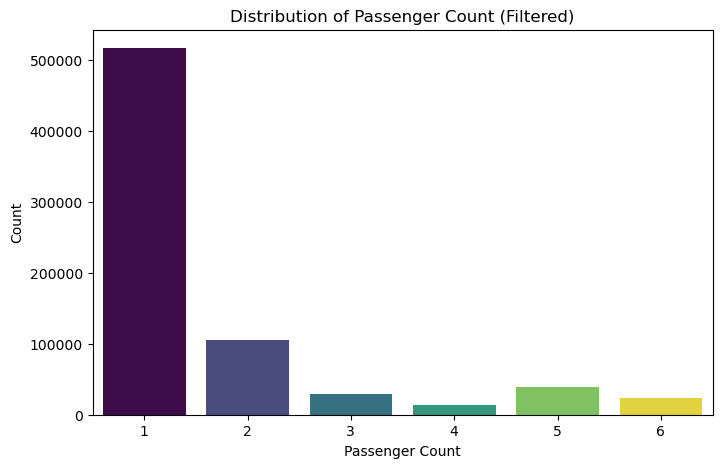

In [23]:
df_nyc_filtered = df_nyc_filtered[df_nyc_filtered['passenger_count'] > 0].copy()

df_nyc_filtered = df_nyc_filtered[df_nyc_filtered['passenger_count'] <= 6].copy()

print(f"\nShape after filtering passenger_count outliers: {df_nyc_filtered.shape}")

print('\nValue counts for filtered passenger_count:')
print(df_nyc_filtered['passenger_count'].value_counts())
print('\nDescriptive statistics for filtered passenger_count:')
print(df_nyc_filtered['passenger_count'].describe())

plt.figure(figsize=(8, 5))
sns.countplot(x='passenger_count', data=df_nyc_filtered, palette='viridis', hue='passenger_count', legend=False)
plt.title('Distribution of Passenger Count (Filtered)')
plt.xlabel('Passenger Count')
plt.ylabel('Count')
plt.show()

In [24]:
NYC_BOUNDS = {
    'min_longitude': -74.25,
    'max_longitude': -73.70,
    'min_latitude': 40.50,
    'max_latitude': 40.92
}

df_nyc_filtered = df_nyc_filtered[
    (df_nyc_filtered['pickup_longitude'] >= NYC_BOUNDS['min_longitude']) &
    (df_nyc_filtered['pickup_longitude'] <= NYC_BOUNDS['max_longitude']) &
    (df_nyc_filtered['pickup_latitude'] >= NYC_BOUNDS['min_latitude']) &
    (df_nyc_filtered['pickup_latitude'] <= NYC_BOUNDS['max_latitude']) &
    (df_nyc_filtered['dropoff_longitude'] >= NYC_BOUNDS['min_longitude']) &
    (df_nyc_filtered['dropoff_longitude'] <= NYC_BOUNDS['max_longitude']) &
    (df_nyc_filtered['dropoff_latitude'] >= NYC_BOUNDS['min_latitude']) &
    (df_nyc_filtered['dropoff_latitude'] <= NYC_BOUNDS['max_latitude'])
].copy()

print(f"\nShape after filtering geographical outliers: {df_nyc_filtered.shape}")

print('\nDescriptive statistics for pickup_longitude (Filtered):')
print(df_nyc_filtered['pickup_longitude'].describe())
print('\nDescriptive statistics for pickup_latitude (Filtered):')
print(df_nyc_filtered['pickup_latitude'].describe())


Shape after filtering geographical outliers: (728564, 13)

Descriptive statistics for pickup_longitude (Filtered):
count    728564.000000
mean        -73.973541
std           0.037960
min         -74.225800
25%         -73.991867
50%         -73.981766
75%         -73.967400
max         -73.703575
Name: pickup_longitude, dtype: float64

Descriptive statistics for pickup_latitude (Filtered):
count    728564.000000
mean         40.750930
std           0.027955
min          40.520481
25%          40.737354
50%          40.754074
75%          40.768311
max          40.914124
Name: pickup_latitude, dtype: float64


In [25]:
df_nyc_filtered['pickup_day'] = df_nyc_filtered['pickup_datetime'].dt.day
df_nyc_filtered['pickup_month'] = df_nyc_filtered['pickup_datetime'].dt.month
df_nyc_filtered['pickup_year'] = df_nyc_filtered['pickup_datetime'].dt.year
df_nyc_filtered['pickup_week_of_year'] = df_nyc_filtered['pickup_datetime'].dt.isocalendar().week.astype(int)

df_nyc_filtered['dropoff_hour'] = df_nyc_filtered['dropoff_datetime'].dt.hour
df_nyc_filtered['dropoff_day_of_week'] = df_nyc_filtered['dropoff_datetime'].dt.dayofweek

print("New time-based features created:")
print(df_nyc_filtered[['pickup_datetime', 'pickup_hour', 'pickup_day_of_week', 'pickup_day', 'pickup_month', 'pickup_year', 'pickup_week_of_year', 'dropoff_datetime', 'dropoff_hour', 'dropoff_day_of_week']].head())

New time-based features created:
      pickup_datetime  pickup_hour  pickup_day_of_week  pickup_day  \
0 2016-02-29 16:40:00           16                   0          29   
1 2016-03-11 23:35:00           23                   4          11   
2 2016-02-21 17:59:00           17                   6          21   
3 2016-01-05 09:44:00            9                   1           5   
4 2016-02-17 06:42:00            6                   2          17   

   pickup_month  pickup_year  pickup_week_of_year    dropoff_datetime  \
0             2         2016                    9 2016-02-29 16:47:00   
1             3         2016                   10 2016-03-11 23:53:00   
2             2         2016                    7 2016-02-21 18:26:00   
3             1         2016                    1 2016-01-05 10:03:00   
4             2         2016                    7 2016-02-17 06:56:00   

   dropoff_hour  dropoff_day_of_week  
0            16                    0  
1            23              

In [26]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = R * c
    return distance

df_nyc_filtered['distance_km'] = df_nyc_filtered.apply(lambda row: haversine_distance(
    row['pickup_latitude'], row['pickup_longitude'],
    row['dropoff_latitude'], row['dropoff_longitude']
), axis=1)

print("Haversine distance calculated. Displaying first few rows with new feature:")
print(df_nyc_filtered[['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude', 'distance_km']].head())

Haversine distance calculated. Displaying first few rows with new feature:
   pickup_latitude  pickup_longitude  dropoff_latitude  dropoff_longitude  \
0        40.778873        -73.953918         40.771164         -73.963875   
1        40.731743        -73.988312         40.694931         -73.994751   
2        40.721458        -73.997314         40.774918         -73.948029   
3        40.759720        -73.961670         40.780628         -73.956779   
4        40.708469        -74.017120         40.740631         -73.988182   

   distance_km  
0     1.199072  
1     4.129111  
2     7.250752  
3     2.361097  
4     4.328533  


In [27]:
df_nyc_filtered['speed_kmh'] = (df_nyc_filtered['distance_km'] / (df_nyc_filtered['trip_duration'] / 3600))

df_nyc_filtered['speed_kmh'] = df_nyc_filtered['speed_kmh'].replace([np.inf, -np.inf], np.nan)
df_nyc_filtered['speed_kmh'] = df_nyc_filtered['speed_kmh'].fillna(0)

print("Speed (km/h) calculated. Displaying first few rows with new feature:")
print(df_nyc_filtered[['trip_duration', 'distance_km', 'speed_kmh']].head())

print('\nDescriptive statistics for speed_kmh:')
print(df_nyc_filtered['speed_kmh'].describe())

Speed (km/h) calculated. Displaying first few rows with new feature:
   trip_duration  distance_km  speed_kmh
0            400     1.199072  10.791651
1           1100     4.129111  13.513455
2           1635     7.250752  15.964959
3           1141     2.361097   7.449560
4            848     4.328533  18.375850

Descriptive statistics for speed_kmh:
count    728564.000000
mean         14.383317
std           8.704536
min           0.000000
25%           9.125170
50%          12.793964
75%          17.830015
max        1410.023567
Name: speed_kmh, dtype: float64


In [28]:
features = ['vendor_id', 'passenger_count',
            'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
            'pickup_hour', 'pickup_day_of_week', 'pickup_day', 'pickup_month', 'pickup_year', 'pickup_week_of_year',
            'distance_km', 'speed_kmh']

X = df_nyc_filtered[features]
y = df_nyc_filtered['trip_duration']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("Selected Features:")
print(X.columns.tolist())

Features (X) shape: (728564, 14)
Target (y) shape: (728564,)
Selected Features:
['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'pickup_hour', 'pickup_day_of_week', 'pickup_day', 'pickup_month', 'pickup_year', 'pickup_week_of_year', 'distance_km', 'speed_kmh']


In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (582851, 14)
X_test shape: (145713, 14)
y_train shape: (582851,)
y_test shape: (145713,)


In [30]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

print("Training Linear Regression model...")
linear_model.fit(X_train, y_train)

print("Linear Regression model training complete.")

Training Linear Regression model...
Linear Regression model training complete.


Linear Regression Model Evaluation on Test Set:
RMSE: 2944.6291
MAE: 333.3055
R-squared: 0.0623


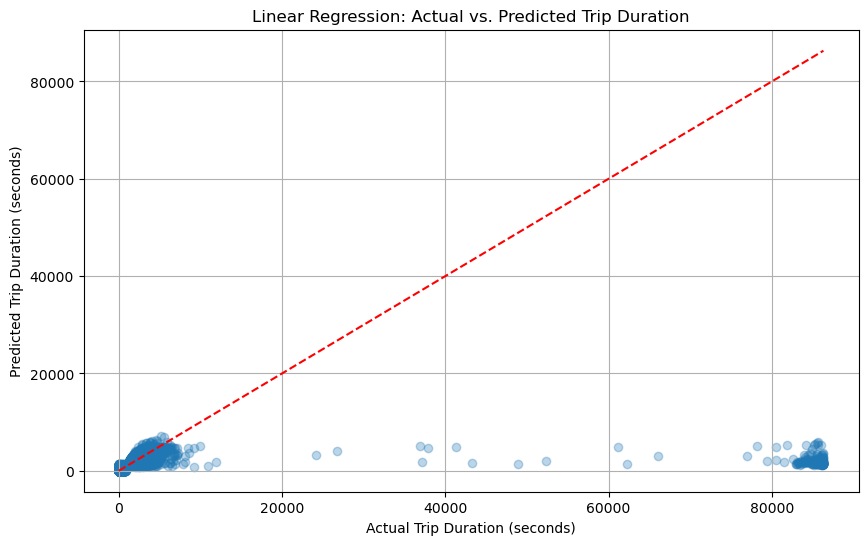

In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_linear = linear_model.predict(X_test)

y_pred_linear[y_pred_linear < 0] = 0

rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
mae_linear = mean_absolute_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression Model Evaluation on Test Set:")
print(f"RMSE: {rmse_linear:.4f}")
print(f"MAE: {mae_linear:.4f}")
print(f"R-squared: {r2_linear:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_linear, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Trip Duration (seconds)')
plt.ylabel('Predicted Trip Duration (seconds)')
plt.title('Linear Regression: Actual vs. Predicted Trip Duration')
plt.grid(True)
plt.show()